# Stark map of Yb174

This notebook computes a Stark map for Yb174. The calculation follows the field-dependent energies near the $49.7\,S_0$ Rydberg state and highlights how nearby states mix with this state in an applied electric field.

In [ ]:
# %pip install -q pairinteraction # Uncomment for installation on Colab

import matplotlib.pyplot as plt
import numpy as np
import pairinteraction.real as pi
from pairinteraction.visualization.colormaps import alphamagma

if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)

The reference state is the $\nu = 49.7, S_0, m=0$ state.
We build an atomic basis around this state, sweep a static electric field along the quantization axis, diagonalize the Hamiltonian for each field value, and store both the eigenenergies and the overlap of each eigenstate with the reference state.

In [8]:
ket = pi.KetAtom("Yb174_mqdt", nu=49.7, s=0, j=0, m=0)
basis = pi.BasisAtom(ket.species, nu=(ket.nu - 5, ket.nu + 5), j=(0, 7))

efields = np.linspace(0, 1.5, 200)
systems = [
    pi.SystemAtom(basis).set_electric_field([0, 0, efield], unit="V/cm") for efield in efields
]
pi.diagonalize(systems)

energies = np.array(
    [system.get_eigenenergies(unit="MHz") - ket.get_energy("MHz") for system in systems]
)
overlaps = np.array([system.get_eigenbasis().get_overlaps(ket) for system in systems])

For the plot, the low-field quadratic Stark shift is removed by extracting an effective static polarizability from the energy at zero field and near $0.5\,\mathrm{V/cm}$.
The gray lines show the shifted eigenenergies, while the colored markers encode the calculated overlap with the reference $S_0$ state.
One can clearly see the avoided crossing with the nearby $F_3$ Rydberg state, which mixes with the $S_0$ state and causes a significant deviation from the quadratic Stark shift.

Polarizability: 513.89 MHz/(V/cm)^2


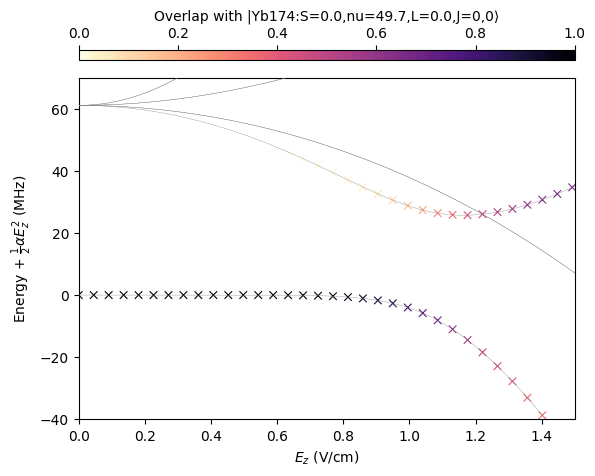

In [13]:
fig = plt.figure()
grid = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[0.06, 2], hspace=0.10)
ax = fig.add_subplot(grid[1, 0])

ind0, ind1 = 0, np.argmin(np.abs(efields - 0.5))
energy0, energy1 = [
    systems[ind].get_corresponding_energy(ket, unit="MHz") for ind in [ind0, ind1]
]
polarizability = -2 * (energy1 - energy0) / (efields[ind1] ** 2 - efields[ind0] ** 2)
print(f"Polarizability: {polarizability:.2f} MHz/(V/cm)^2")

energies_shifted = energies + 0.5 * polarizability * efields[:, None] ** 2
ax.plot(efields, energies_shifted, c="0.5", ls="-", lw=0.25, zorder=10)

step_size = 6
x_repeated = np.hstack(
    [
        val * np.ones_like(es)
        for val, es in zip(efields[::step_size], energies_shifted[::step_size], strict=True)
    ]
)
energies_shifted_flattened = np.hstack(energies_shifted[::step_size])
overlaps_flattened = np.hstack(overlaps[::step_size])
sorter = np.argsort(overlaps_flattened)

scat = ax.scatter(
    x_repeated[sorter],
    energies_shifted_flattened[sorter],
    c=overlaps_flattened[sorter],
    s=30,
    cmap=alphamagma,
    marker="x",
    linewidths=0.8,
)

cax = fig.add_subplot(grid[0, 0])
fig.colorbar(scat, cax=cax, label=rf"Overlap with {ket}", location="top")

ax.set_xlim(0, 1.5)
ax.set_ylim(-40, 70)

ax.set_xlabel(r"$E_z$ (V/cm)")
ax.set_ylabel(r"Energy + $\frac{1}{2} \alpha E_z^2$ (MHz)")

plt.show()